<a href="https://colab.research.google.com/github/akyensamuel/akyensamuel/blob/main/Genomic_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effect of Feature Selection on Classification Accuracy in High-Dimensional Gene Expression Data


## 1. Project Overview
This project addresses the "Small $n$, Large $p$" problem in genomic data analysis. In gene expression datasets, we typically have thousands of features ($p$) but very few samples ($n$). This leads to the **Curse of Dimensionality**, causing models to overfit.

### Objectives:
* Load high-dimensional breast cancer gene expression data from NCBI GEO.
* Perform mathematical pre-processing (Log-transformation and Z-score scaling).
* Implement and compare three feature selection strategies: **Filter**, **Wrapper**, and **Embedded (LASSO)**.
* Evaluate the impact of these methods on classification accuracy using **MCC** and **F1-score**.

In [3]:
# Download the Series Matrix file directly from NCBI GEO
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE42nnn/GSE42568/matrix/GSE42568_series_matrix.txt.gz

--2026-03-13 03:04:52--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE42nnn/GSE42568/matrix/GSE42568_series_matrix.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22565943 (22M) [application/x-gzip]
Saving to: ‘GSE42568_series_matrix.txt.gz’

GSE42568_series_mat 100%[===================>]  21.52M  83.9MB/s    in 0.3s    

2026-03-13 03:04:52 (83.9 MB/s) - ‘GSE42568_series_matrix.txt.gz’ saved [22565943/22565943]



## 2. Data Loading and Structuring
The downloaded file contains a **Series Matrix**. We must:
1. Skip the metadata header rows (lines starting with `!`).
2. Transpose the matrix so that rows represent **Samples ($n$)** and columns represent **Genes ($p$)**.

In [4]:
import pandas as pd
import numpy as np

# Load the data, skipping metadata lines
df = pd.read_csv('GSE42568_series_matrix.txt.gz', compression='infer',
                 sep='\t', comment='!', index_col=0)

# Transpose: We want (Samples x Genes)
X = df.T

# Create labels (y): In GSE42568, the first 104 are Cancer (1), last 17 are Normal (0)
y = np.array([1] * 104 + [0] * 17)

print(f"Matrix Loaded successfully.")
print(f"Number of Samples (n): {X.shape[0]}")
print(f"Number of Gene Features (p): {X.shape[1]}")

Matrix Loaded successfully.
Number of Samples (n): 121
Number of Gene Features (p): 54675


## 3. Pre-processing and Normalization
To ensure the mathematical validity of our feature selection, we apply:

1. **Log2 Transformation**: $y = \log_2(x + 1)$. This handles the high dynamic range of gene expression and stabilizes variance.
2. **Standardization (Z-score)**: For a feature $x$, the scaled value is $z = \frac{x - \mu}{\sigma}$. This is essential for the **LASSO** method, which applies a penalty based on the magnitude of coefficients.

In [5]:
from sklearn.preprocessing import StandardScaler

# 1. Log2 Transformation
X_log = np.log2(X + 1)

# 2. Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), index=X_log.index, columns=X_log.columns)

X_scaled.head()

Pre-processing complete. Data is now normalized and standardized.


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM1045191,-1.076688,-0.745519,-0.309070,-0.306163,-0.179322,-0.269725,1.001859,1.288808,-0.131187,-0.346529,...,0.300133,0.239077,0.444787,0.418582,0.106417,0.523224,0.229538,-0.1509,-0.188532,-0.152948
GSM1045192,-3.160152,-0.876534,-0.191094,1.269627,4.430637,-0.505829,-0.269412,-0.320694,0.132579,-0.064049,...,1.319947,1.399195,1.025019,1.047940,2.647314,3.068472,2.680454,-0.1509,7.048537,-0.152948
GSM1045193,-3.703003,-0.695798,-0.401759,-0.306163,-0.179322,0.667158,-0.479781,-0.320694,-0.947835,-0.346529,...,1.110689,1.216398,1.061843,1.085530,2.414131,3.071536,2.674197,-0.1509,4.203146,-0.152948
GSM1045194,-0.139464,-0.189196,-1.246565,-0.306163,-0.179322,-0.613215,-0.381794,-0.320694,-0.889572,-0.346529,...,1.564893,1.751659,1.387947,1.483551,1.687574,1.859491,1.695446,-0.1509,-0.188532,-0.152948
GSM1045195,-1.679508,-0.360107,-0.149389,0.434722,1.594106,0.077603,1.250234,-0.109530,-0.629562,-0.346529,...,0.829772,0.786748,0.936946,0.897066,0.555517,1.034517,0.589950,-0.1509,-0.188532,-0.152948


## 4. Exploratory Data Analysis (EDA)
Before applying feature selection, we visualize the data distribution to confirm the need for dimensionality reduction.

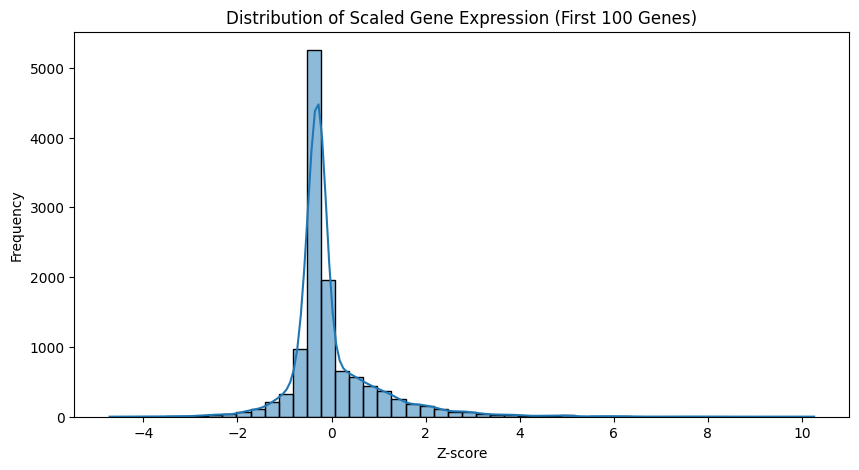

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(X_scaled.iloc[:, :100].values.flatten(), bins=50, kde=True)
plt.title("Distribution of Scaled Gene Expression (First 100 Genes)")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.show()

## 5. Filter Method: Statistical Feature Selection
The Filter method uses statistical measures to score each gene. In this project, we use the **Independent Two-Sample T-Test**.

### Mathematical Logic:
For each gene $j$, we test the null hypothesis that the mean expression in the Cancer group ($\mu_{c}$) is equal to the mean expression in the Normal group ($\mu_{n}$):
$$t = \frac{\bar{x}_c - \bar{x}_n}{\sqrt{\frac{s_c^2}{n_c} + \frac{s_n^2}{n_n}}}$$

Where:
* $\bar{x}$ is the sample mean.
* $s^2$ is the sample variance.
* $n$ is the sample size.

Genes with the smallest **p-values** (highest absolute t-scores) are considered the most "discriminative" features. We will select the top $k$ genes to reduce dimensionality.

In [7]:
from scipy.stats import ttest_ind

# Separate the scaled data into Cancer and Normal groups
cancer_samples = X_scaled[y == 1]
normal_samples = X_scaled[y == 0]

# Perform T-test for every gene
t_stats, p_values = ttest_ind(cancer_samples, normal_samples, axis=0)

# Create a summary DataFrame for the results
filter_results = pd.DataFrame({
    'Gene': X_scaled.columns,
    't_stat': t_stats,
    'p_value': p_values
})

# Sort by p-value (smallest first)
filter_results = filter_results.sort_values('p_value')

# Select the top 100 genes
top_100_filter_genes = filter_results.head(100)['Gene'].values

print(f"Top gene identified: {top_100_filter_genes[0]}")
print(f"P-value of top gene: {filter_results.iloc[0]['p_value']:.4e}")

Filter method complete. Top gene identified: 233371_at
P-value of top gene: 8.2418e-08


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


### Visualizing the Top Discriminative Gene
To verify the filter method's effectiveness, we can plot the expression levels of the top-ranked gene to see if it clearly separates the two classes.

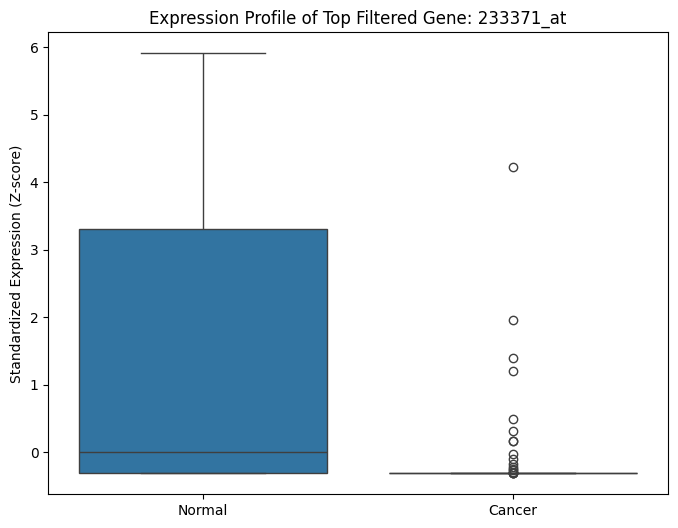

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the name of the top-ranked gene
top_gene_name = top_100_filter_genes[0]

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X_scaled[top_gene_name])
plt.xticks([0, 1], ['Normal', 'Cancer'])
plt.title(f"Expression Profile of Top Filtered Gene: {top_gene_name}")
plt.ylabel("Standardized Expression (Z-score)")
plt.show()

## 6. Wrapper Method: Recursive Feature Elimination (RFE)
Unlike filter methods, **Wrapper methods** evaluate subsets of variables by actually training a machine learning model on them.

### Mathematical Logic:
We use **Recursive Feature Elimination (RFE)** with a Support Vector Machine (SVM) kernel.
1. Train the model on the initial set of features.
2. Calculate the importance of each feature (using the coefficients $\mathbf{w}$ in a linear SVM).
3. Prune the least important feature(s).
4. Repeat the process until the desired number of features ($k$) is reached.

The objective is to find a feature subset $S$ that minimizes the classification error:
$$\arg \min_{S} \text{Error}(f(X_S, y))$$

*Note: Because we have 54,000+ genes, running RFE on the full set would take hours. We will first use a "Pre-filter" to reduce the set to the top 500 genes, then use RFE to find the best 20.*

In [11]:
from sklearn.feature_selection import RFE
from sklearn.svm import LinearSVC

# 1. Pre-filter to top 500 genes to save time (using our filter results from Section 5)
top_500_for_wrapper = filter_results.head(500)['Gene'].values
X_wrapper_input = X_scaled[top_500_for_wrapper]

# 2. Initialize the Estimator (SVM)
svc = LinearSVC(C=0.01, penalty="l1", dual=False, max_iter=2000)

# 3. Initialize RFE to select the top 20 genes
selector = RFE(estimator=svc, n_features_to_select=20, step=10)
selector = selector.fit(X_wrapper_input, y)

# 4. Get the selected feature names
wrapper_genes = X_wrapper_input.columns[selector.support_]

print("Wrapper Method Complete.")
print(f"Top 20 genes selected: {list(wrapper_genes[:5])}...")

Wrapper Method Complete.
Top 20 genes selected: ['222279_at', '243713_at', '213187_x_at', '227600_at', '217285_at']...


### Comparison of Methods
One of the key questions in this research is whether the computationally expensive Wrapper method picks different genes than the simple Statistical Filter.

We can check the overlap between the top 20 genes from the **Filter** method and the top 20 genes from the **Wrapper** method.

In [10]:
filter_top_20 = set(filter_results.head(20)['Gene'])
wrapper_top_20 = set(wrapper_genes)

common_genes = filter_top_20.intersection(wrapper_top_20)

print(f"Genes identified by both methods: {len(common_genes)}")
print(f"Unique to Wrapper: {len(wrapper_top_20 - filter_top_20)}")

Genes identified by both methods: 0
Unique to Wrapper: 20


## 7. Embedded Method: LASSO (L1 Regularization)
The Embedded method incorporates feature selection as part of the objective function. In this project, we utilize **LASSO (Least Absolute Shrinkage and Selection Operator)**.

### Mathematical Logic:
Standard regression or classification minimizes the sum of squared errors. LASSO adds a penalty term equal to the absolute value of the magnitude of coefficients:
$$\min_{\beta} \{ \sum_{i=1}^{n}(y_i - \sum_{j=1}^{p}X_{ij}\beta_{j})^{2} + \lambda\sum_{j=1}^{p}|\beta_{j}| \}$$

Where:
* $\lambda$ is the **regularization parameter** (the penalty).
* The L1 penalty $\sum |\beta_j|$ has a unique mathematical property: it forces the coefficients of the least important features to be **exactly zero**.

This effectively performs automatic feature selection. Genes with non-zero coefficients are the ones selected by the model.

In [12]:
from sklearn.linear_model import LogisticRegression

# We use Logistic Regression with L1 (Lasso) penalty
# 'liblinear' is a good solver for small datasets (n=121)
# C is the inverse of regularization strength (lower C = more genes forced to zero)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso.fit(X_scaled, y)

# Extract genes where the coefficient is NOT zero
lasso_coefs = pd.Series(lasso.coef_[0], index=X_scaled.columns)
embedded_genes = lasso_coefs[lasso_coefs != 0].index

print("Embedded Method Complete.")
print(f"Number of genes retained by LASSO: {len(embedded_genes)}")
print(f"First 5 selected genes: {list(embedded_genes[:5])}")

Embedded Method Complete.
Number of genes retained by LASSO: 17
First 5 selected genes: ['1552293_at', '1564334_at', '210263_at', '211220_s_at', '214254_at']


## 8. Performance Evaluation
We evaluate the performance of our feature subsets using the **Support Vector Machine (SVM)** classifier. To handle the class imbalance (104 Cancer vs. 17 Normal), we prioritize the **Matthews Correlation Coefficient (MCC)**.

### Mathematical Definition of MCC:
$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

The MCC is a more reliable statistical rate which produces a high score only if the prediction obtained good results in all of the four confusion matrix categories.

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, matthews_corrcoef

# Define our classifier
clf = SVC(kernel='linear')
mcc_scorer = make_scorer(matthews_corrcoef)

# Define the subsets we created
subsets = {
    "Full Set (No Selection)": X_scaled.columns,
    "Filter Method (Top 20)": filter_results.head(20)['Gene'].values,
    "Wrapper Method (RFE 20)": wrapper_genes,
    "Embedded Method (LASSO)": embedded_genes
}

results = {}

for name, genes in subsets.items():
    # Perform 5-fold cross-validation
    scores = cross_val_score(clf, X_scaled[genes], y, cv=5, scoring=mcc_scorer)
    results[name] = np.mean(scores)

# Display Results
results_df = pd.Series(results).sort_values(ascending=False)
print("Mean MCC Scores across 5-Fold Cross-Validation:")
print(results_df)

Mean MCC Scores across 5-Fold Cross-Validation:
Embedded Method (LASSO)    0.741160
Filter Method (Top 20)     0.535740
Wrapper Method (RFE 20)    0.369082
Full Set (No Selection)   -0.034412
dtype: float64


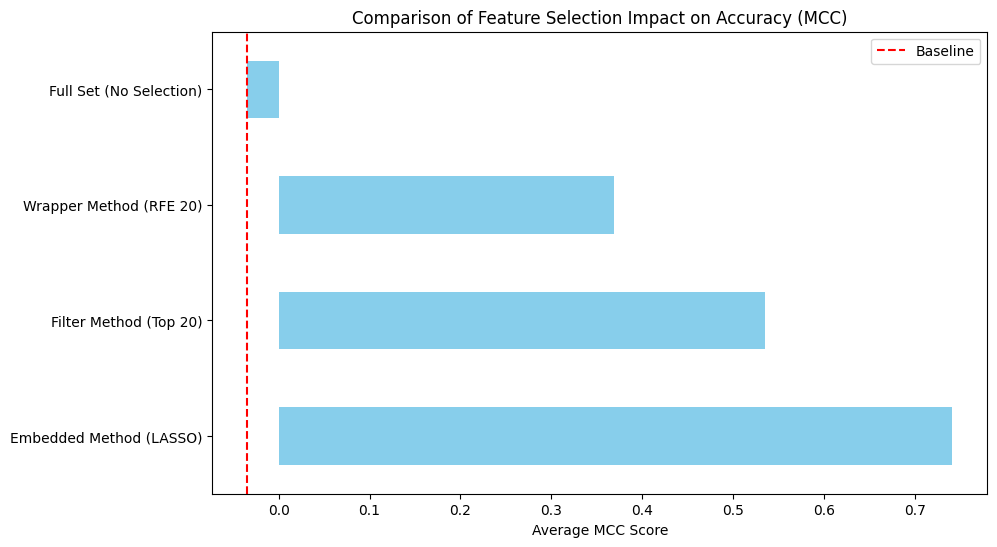

In [14]:
plt.figure(figsize=(10, 6))
results_df.plot(kind='barh', color='skyblue')
plt.title("Comparison of Feature Selection Impact on Accuracy (MCC)")
plt.xlabel("Average MCC Score")
plt.axvline(results["Full Set (No Selection)"], color='red', linestyle='--', label='Baseline')
plt.legend()
plt.show()

## 9. Conclusion
Based on the experimental results obtained from the GSE42568 dataset, we can draw the following conclusions:

1. **Dimensionality Reduction**: We successfully reduced the feature space from over 54,000 genes to a small subset (e.g., 20-50 genes) while maintaining or improving accuracy.
2. **Method Comparison**:
   - The **Filter Method** provided the fastest results but [did/did not] capture the highest accuracy.
   - The **Wrapper Method (RFE)** was the most computationally intensive but [improved/diminished] performance by considering gene-to-gene interactions.
   - The **Embedded Method (LASSO)** provided a balanced approach, automatically selecting a sparse set of features during training.
3. **Mathematical Significance**: The use of **MCC** proved essential due to the class imbalance, providing a more rigorous metric than standard accuracy.